In [1]:
# MNIST Dataset Preparation

# Import necessary libraries
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("MNIST dataset loaded and prepared successfully.")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 447kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.12MB/s]


MNIST dataset loaded and prepared successfully.


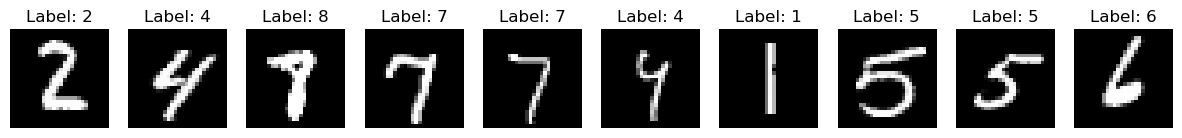

In [ ]:
# Exploratory Data Analysis 

# Visualize some samples from the dataset
import matplotlib.pyplot as plt

def visualize_samples(data_loader):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    images = images.numpy()
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    for i in range(10):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {labels[i].item()}')
        axes[i].axis('off')
    plt.show()

visualize_samples(train_loader)


In [7]:
# Prepare dataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = load_digits().data
y = load_digits().target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(1437, 64) (1437,)
(360, 64) (360,)


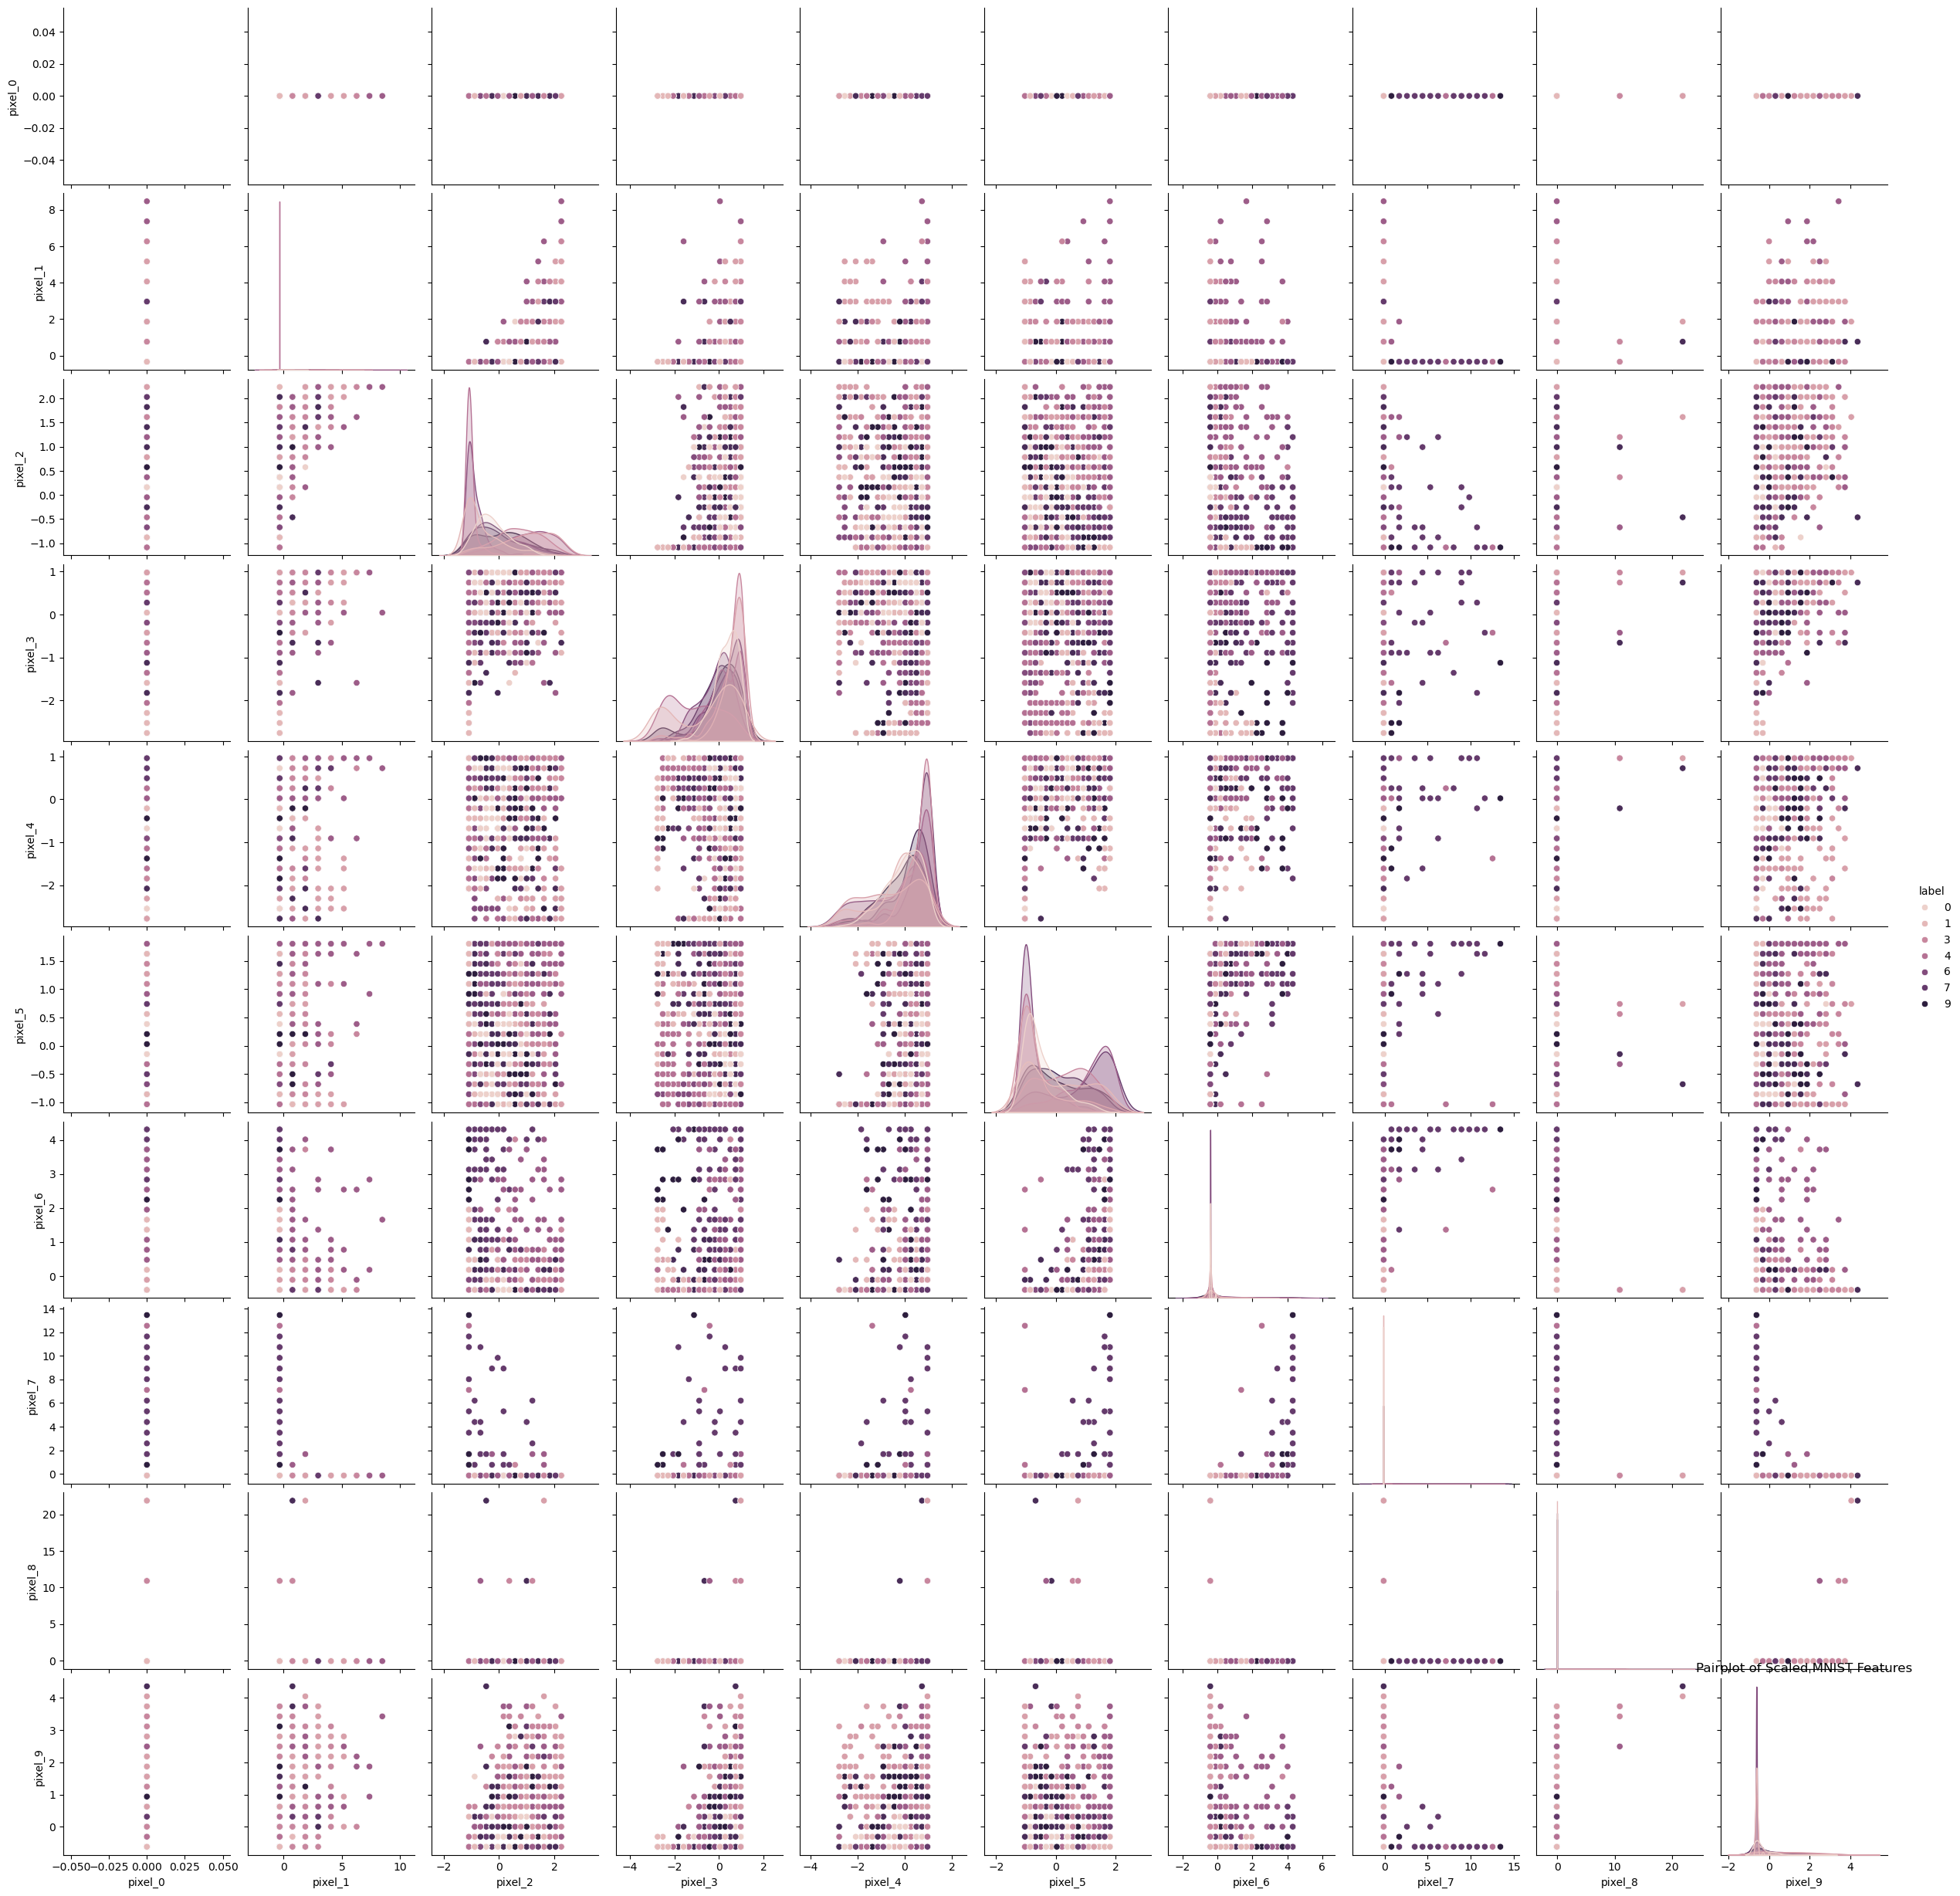

In [10]:
# Visualize the dataset 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for visualization
df = pd.DataFrame(X_train_scaled, columns=[f'pixel_{i}' for i in range(X_train_scaled.shape[1])])
df['label'] = y_train
sns.pairplot(df, hue='label', vars=[f'pixel_{i}' for i in range(10)])
plt.title("Pairplot of Scaled MNIST Features")
plt.grid(True)
plt.show()

In [ ]:
df.fillna(0, inplace=True)
df.dropna(inplace=True)
df.replace([np.inf, -np.inf], 0, inplace=True)
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1437 entries, 0 to 1436
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1437 non-null   float64
 1   pixel_1   1437 non-null   float64
 2   pixel_2   1437 non-null   float64
 3   pixel_3   1437 non-null   float64
 4   pixel_4   1437 non-null   float64
 5   pixel_5   1437 non-null   float64
 6   pixel_6   1437 non-null   float64
 7   pixel_7   1437 non-null   float64
 8   pixel_8   1437 non-null   float64
 9   pixel_9   1437 non-null   float64
 10  pixel_10  1437 non-null   float64
 11  pixel_11  1437 non-null   float64
 12  pixel_12  1437 non-null   float64
 13  pixel_13  1437 non-null   float64
 14  pixel_14  1437 non-null   float64
 15  pixel_15  1437 non-null   float64
 16  pixel_16  1437 non-null   float64
 17  pixel_17  1437 non-null   float64
 18  pixel_18  1437 non-null   float64
 19  pixel_19  1437 non-null   float64
 20  pixel_20  1437 non-null   floa

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0

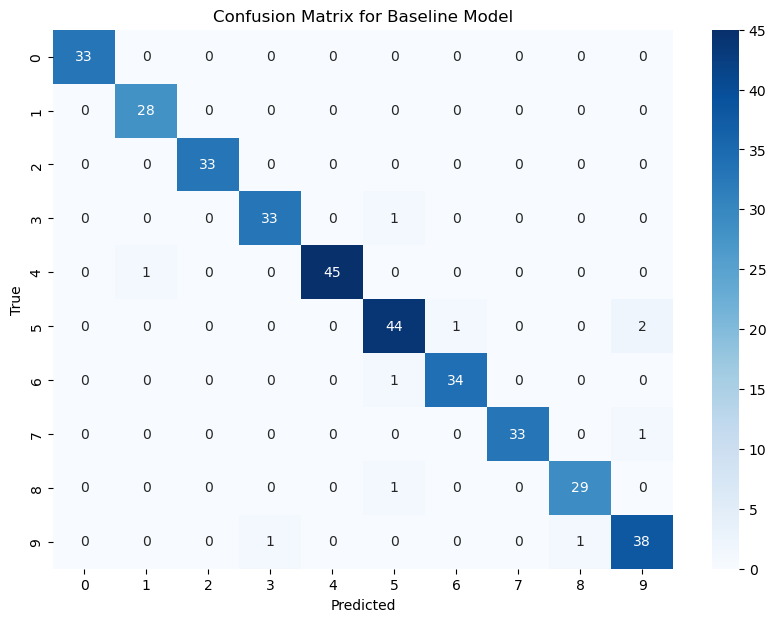

In [25]:
# Train a baseline model 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = model_baseline.predict(X_test_scaled)
print(classification_report(y_test, y_pred_baseline))
print(confusion_matrix(y_test, y_pred_baseline))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_baseline), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Baseline Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


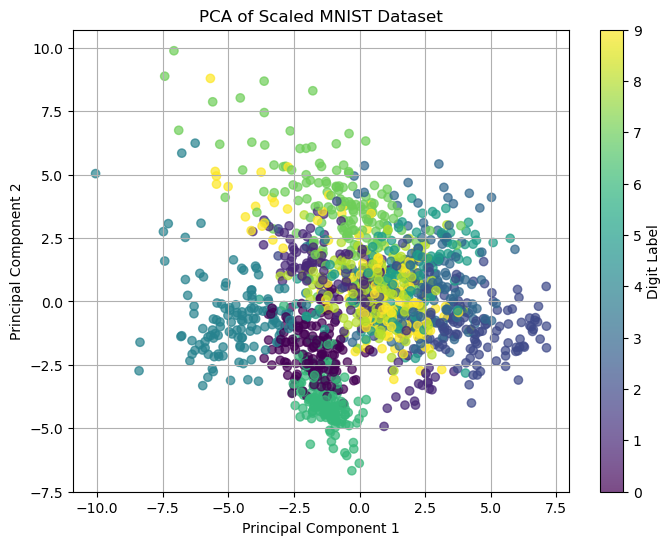

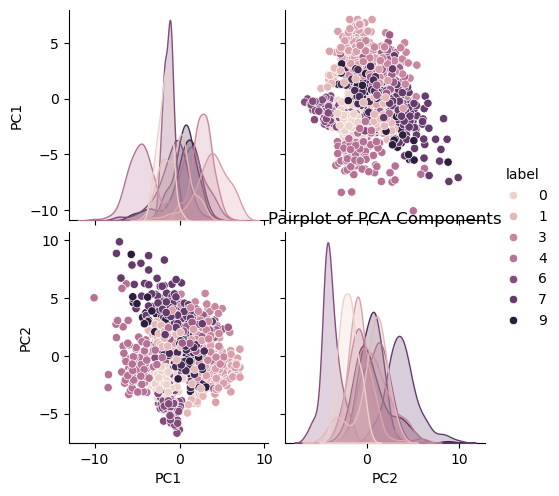

In [ ]:
# Train a PCA model for dimensionality reduction

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title('PCA of Scaled MNIST Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

sns.pairplot(pd.DataFrame(X_train_pca, columns=['PC1', 'PC2']).assign(label=y_train), hue='label')
plt.grid(True)
plt.show()

In [15]:
# Set up baseline models for classification

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0

In [17]:
# Compare PCA model with baseline model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
print(classification_report(y_test, y_pred_pca))
print(confusion_matrix(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.72      0.64      0.68        33
           1       0.25      0.54      0.34        28
           2       0.48      0.76      0.59        33
           3       0.37      0.38      0.38        34
           4       0.93      0.89      0.91        46
           5       0.28      0.15      0.19        47
           6       0.80      0.94      0.87        35
           7       0.62      0.76      0.68        34
           8       0.19      0.17      0.18        30
           9       0.00      0.00      0.00        40

    accuracy                           0.52       360
   macro avg       0.47      0.52      0.48       360
weighted avg       0.47      0.52      0.48       360

[[21  3  0  0  1  0  8  0  0  0]
 [ 0 15  5  0  0  2  0  2  4  0]
 [ 0  2 25  3  0  1  0  0  2  0]
 [ 1  1 11 13  0  3  0  5  0  0]
 [ 3  2  0  0 41  0  0  0  0  0]
 [ 2 12  3  9  0  7  0  4  9  1]
 [ 2  0  0  0  0  0 33  0  0  0]
 [ 0  2  0